In [ ]:
!pip -q install kagglehub nltk tqdm tensorflow==2.15.0

import os, re, gc, random, pickle, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import corpus_bleu
import kagglehub

print('GPU:', tf.config.list_physical_devices('GPU'))
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Dataset**

In [ ]:
path = kagglehub.dataset_download('adityajn105/flickr8k')
print('Path:', path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path: /kaggle/input/flickr8k


In [ ]:
caption_file=None; image_dir=None
for root,dirs,files in os.walk(path):
    for f in files:
        if ('caption' in f.lower() or 'token' in f.lower()) and f.endswith(('.txt','.csv')):
            caption_file=os.path.join(root,f)
    for d in dirs:
        if 'image' in d.lower():
            image_dir=os.path.join(root,d)
print('Caption file:', caption_file)
print('Image dir:', image_dir)

Caption file: /kaggle/input/flickr8k/captions.txt
Image dir: /kaggle/input/flickr8k/Images


# **Load captions**

In [ ]:
mapping={}
with open(caption_file,'r',encoding='utf-8',errors='ignore') as f:
    for line in f.readlines():
        if line.lower().startswith('image'): continue
        parts=line.strip().split(',',1) if ',' in line else line.strip().split('\t',1)
        if len(parts)<2: continue
        img,cap=parts[0],parts[1]
        img=img.split('#')[0]
        cap=cap.lower()
        cap=re.sub(r'[^a-z ]',' ',cap)
        cap=' '.join(cap.split())
        cap='<start> '+cap+' <end>'
        mapping.setdefault(img,[]).append(cap)

images=list(mapping.keys())
random.shuffle(images)
train_imgs=images[:6000]
val_imgs=images[6000:7000]
test_imgs=images[7000:]

# **Tokenizer**

In [ ]:
train_caps=[]
for i in train_imgs: train_caps.extend(mapping[i])

tok=tf.keras.preprocessing.text.Tokenizer(oov_token='<unk>', filters='')
tok.fit_on_texts(train_caps)
word_index=tok.word_index
index_word={v:k for k,v in word_index.items()}
vocab_size=len(word_index)+1
max_len=max(len(c.split()) for c in train_caps)

# **Encoder**

In [ ]:
IMG_SIZE=224
base=EfficientNetB0(include_top=False, weights='imagenet')

# Freeze semua layer dulu
base.trainable=False

# Fine-tune: unfreeze 30 layer terakhir EfficientNetB0
FINETUNE_LAYERS = 30
for layer in base.layers[-FINETUNE_LAYERS:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

trainable_count = sum(1 for l in base.layers if l.trainable)
print(f'Trainable layers in EfficientNetB0: {trainable_count}')

inp=layers.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x=base(inp, training=False)
x=layers.GlobalAveragePooling2D()(x)
encoder=Model(inp,x)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Trainable layers in EfficientNetB0: 23


# **Image Loader**

In [ ]:
def load_img(path):
    img=tf.io.read_file(path)
    img=tf.image.decode_jpeg(img, channels=3)
    img=tf.image.resize(img,(IMG_SIZE,IMG_SIZE))
    img=preprocess_input(img)
    return img

# **Precompute features**

In [ ]:
FEATURE_FILE='features.pkl'
if os.path.exists(FEATURE_FILE):
    with open(FEATURE_FILE,'rb') as f:
        feature_dict=pickle.load(f)
    print('Loaded existing features:', len(feature_dict))
else:
    feature_dict={}

BATCH=16
SAVE_EVERY=500
count=0
batch_imgs=[]; batch_names=[]

for img_name in tqdm(images):
    if img_name in feature_dict:
        continue
    p=os.path.join(image_dir,img_name)
    img=load_img(p)
    batch_imgs.append(img)
    batch_names.append(img_name)

    if len(batch_imgs)==BATCH:
        batch=tf.stack(batch_imgs)
        feats=encoder(batch, training=False).numpy()
        for n,fv in zip(batch_names, feats):
            feature_dict[n]=fv
            count+=1
        batch_imgs=[]; batch_names=[]
        gc.collect()

    if count % SAVE_EVERY == 0 and count>0:
        with open(FEATURE_FILE,'wb') as f:
            pickle.dump(feature_dict,f)
        print('Saved checkpoint:', len(feature_dict))

# remaining
if len(batch_imgs)>0:
    batch=tf.stack(batch_imgs)
    feats=encoder(batch, training=False).numpy()
    for n,fv in zip(batch_names, feats):
        feature_dict[n]=fv

with open(FEATURE_FILE,'wb') as f:
    pickle.dump(feature_dict,f)
print('Final features:', len(feature_dict))

 25%|██▍       | 2006/8091 [01:30<04:32, 22.34it/s]

Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000


 25%|██▍       | 2011/8091 [01:30<04:11, 24.13it/s]

Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000
Saved checkpoint: 2000


 25%|██▍       | 2015/8091 [01:30<04:00, 25.28it/s]

...

Saved checkpoint: 8000
Saved checkpoint: 8000


 99%|█████████▉| 8015/8091 [06:05<00:16,  4.51it/s]

Saved checkpoint: 8000
Saved checkpoint: 8000


100%|██████████| 8091/8091 [06:09<00:00, 21.91it/s]


Final features: 8091


generator (low ram)

In [ ]:
def data_generator(img_list, batch_size=256):
    while True:
        X1, X2, y = [], [], []

        for img in img_list:
            feat = feature_dict[img]

            for cap in mapping[img]:
                seq = tok.texts_to_sequences([cap])[0]

                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=max_len,
                        padding='post'
                    )[0]

                    out_seq = tf.keras.utils.to_categorical(
                        out_seq,
                        vocab_size
                    )

                    X1.append(feat)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield (
                            np.array(X1, dtype=np.float32),
                            np.array(X2, dtype=np.int32)
                        ), np.array(y, dtype=np.float32)

                        X1, X2, y = [], [], []

# **Model**

In [ ]:
from tensorflow.keras.regularizers import l2

# Image feature branch
inputs1=layers.Input(shape=(1280,))
fe1=layers.Dropout(0.5)(inputs1)           # naik dari 0.4 -> 0.5
fe2=layers.Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(fe1)  # naik 256->512 + L2
fe3=layers.Dropout(0.5)(fe2)               # tambah dropout setelah dense

# Caption sequence branch
inputs2=layers.Input(shape=(max_len,))
se1=layers.Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2=layers.Dropout(0.5)(se1)               # tambah dropout sebelum LSTM
se3=layers.LSTM(512, return_sequences=True, kernel_regularizer=l2(1e-4))(se2)   # naik 256->512 + L2
se4=layers.LSTM(512, kernel_regularizer=l2(1e-4))(se3)  # tambah layer LSTM kedua
se5=layers.Dropout(0.5)(se4)               # dropout setelah LSTM

# Decoder
x=layers.add([fe3, se5])
x=layers.Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)  # naik 256->512
x=layers.Dropout(0.5)(x)
out=layers.Dense(vocab_size, activation='softmax')(x)

model=Model([inputs1,inputs2], out)

# Optimizer dengan learning rate lebih kecil karena ada fine-tuning
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  1,906,432 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 38, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 38, 512)   │  1,574,912 │ dropout_2[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 512)       │  2,099,200 │ lstm[0][0],       │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7447)      │  3,820,311 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,319,383 (39.37 MB)

 Trainable params: 10,319,383 (39.37 MB)

 Non-trainable params: 0 (0.00 B)

# **Train**

In [ ]:
output_signature = (
    (tf.TensorSpec(shape=(None, 1280), dtype=tf.float32),
     tf.TensorSpec(shape=(None, max_len), dtype=tf.int32)),
    tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
)

train_gen_raw = data_generator(train_imgs, 256)
val_gen_raw = data_generator(val_imgs, 256)

train_dataset = tf.data.Dataset.from_generator(
    lambda: train_gen_raw,
    output_signature=output_signature
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: val_gen_raw,
    output_signature=output_signature
)

steps_per_epoch=1000
val_steps=200

callbacks = [
    # Early stopping dengan patience lebih besar
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,                  # naik dari 3 -> 5
        restore_best_weights=True,
        verbose=1
    ),
    # ReduceLROnPlateau: turunkan LR otomatis jika val_loss stagnan
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                  # kurangi LR jadi 50%
        patience=2,                  # trigger setelah 2 epoch tidak improve
        min_lr=1e-7,
        verbose=1
    ),
    # ModelCheckpoint: simpan model terbaik
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

hist=model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=30,                      # naik dari 15 -> 30, biarkan callbacks yang stop
    callbacks=callbacks
)


Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1402 - loss: 6.2996
Epoch 1: val_loss improved from None to 5.41660, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 44ms/step - accuracy: 0.1604 - loss: 5.6764 - val_accuracy: 0.1787 - val_loss: 5.4166 - learning_rate: 1.0000e-04
Epoch 2/30
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1913 - loss: 5.1457
Epoch 2: val_loss improved from 5.41660 to 4.80420, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.2020 - loss: 5.0201 - val_accuracy: 0.2211 - val_loss: 4.8042 - learning_rate: 1.0000e-04
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2313 - loss: 4.6921
Epoch 3: val_loss improved from 4.80420 to 4.43941, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━

In [ ]:
model.save('cnn_lstm_stable.h5')
print('Model saved')

Model saved


plot

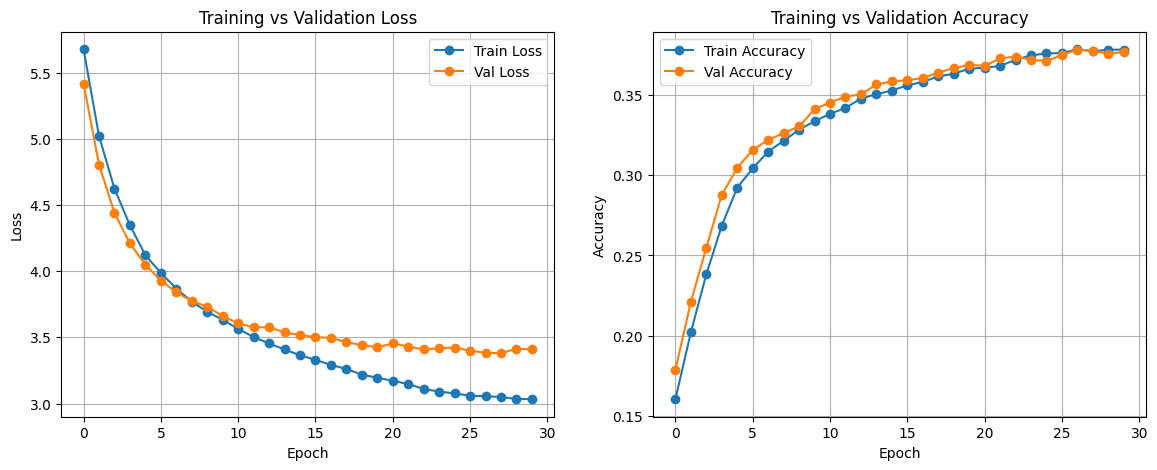

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(hist.history['loss'], marker='o', label='Train Loss')
plt.plot(hist.history['val_loss'], marker='o', label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ACCURACY
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], marker='o', label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

visualisasi

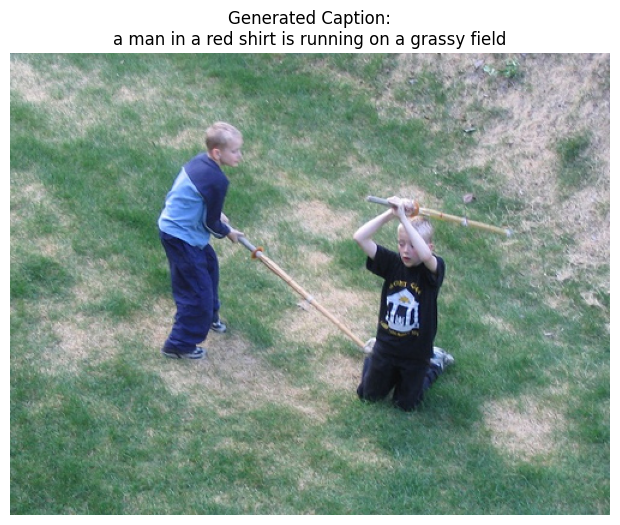

In [ ]:
import random
import matplotlib.pyplot as plt

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption(image_name):
    # Extract image features
    path = os.path.join(image_dir, image_name)
    image = load_img(path)
    image_features = encoder(tf.expand_dims(image, 0), training=False)

    # Initialize caption generation with <start> token
    in_text = '<start>'
    for i in range(max_len):
        sequence = tok.texts_to_sequences([in_text])[0]
        # Changed padding to 'post' for cuDNN compatibility
        sequence = pad_sequences([sequence], maxlen=max_len, padding='post')
        yhat = model.predict([image_features, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tok)
        if word is None:
            break
        in_text += ' ' + word
        if word == '<end>':
            break

    final_caption = in_text.replace('<start> ', '').replace(' <end>', '')
    return final_caption

def show_prediction():
    sample = random.choice(test_imgs)

    img_path = os.path.join(image_dir, sample)
    img = plt.imread(img_path)

    pred_caption = generate_caption(sample)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Generated Caption:\n" + pred_caption, fontsize=12)
    plt.show()

show_prediction()

actual vs generated

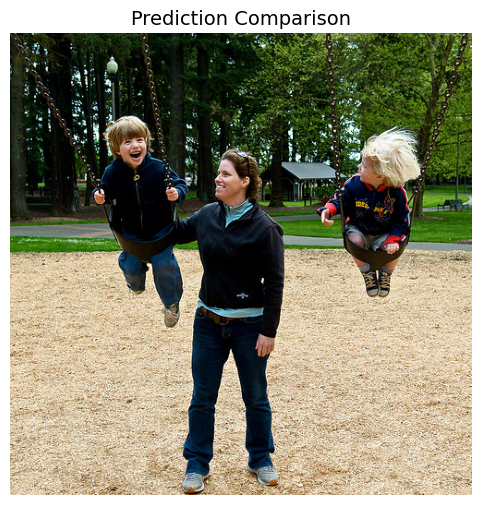

Actual Caption   : a mom is pushing her two kids on the swing
Generated Caption: a young girl in a red shirt is running on a grassy path


In [ ]:
def compare_caption():
    sample = random.choice(test_imgs)

    img_path = os.path.join(image_dir, sample)
    img = plt.imread(img_path)

    pred = generate_caption(sample)
    actual = mapping[sample][0].replace('<start> ','').replace(' <end>','')

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Prediction Comparison", fontsize=14)
    plt.show()

    print("Actual Caption   :", actual)
    print("Generated Caption:", pred)

compare_caption()

bleu

Calculating BLEU scores: 100%|██████████| 1091/1091 [22:31<00:00,  1.24s/it]


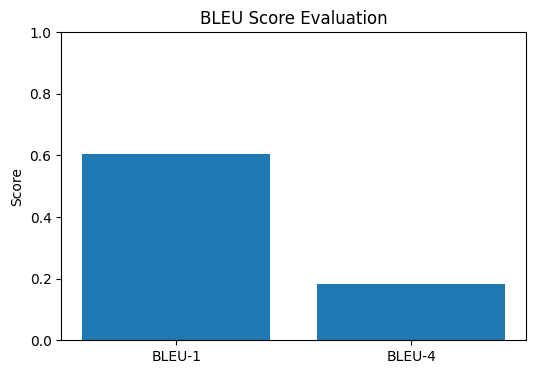

In [ ]:
references = []
hypotheses = []

for img_name in tqdm(test_imgs, desc='Calculating BLEU scores'):
    actual_captions = [cap.replace('<start> ','').replace(' <end>','').split() for cap in mapping[img_name]]
    generated_caption = generate_caption(img_name).split()

    references.append(actual_captions)
    hypotheses.append(generated_caption)

bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

scores = [bleu1, bleu4]
labels = ['BLEU-1', 'BLEU-4']

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title("BLEU Score Evaluation")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()


Corpus BLEU: 100%|██████████| 1091/1091 [22:43<00:00,  1.25s/it]


[Corpus BLEU] BLEU-1: 0.6049  BLEU-2: 0.4194  BLEU-3: 0.2802  BLEU-4: 0.1819


Sentence BLEU: 100%|██████████| 1091/1091 [00:00<00:00, 1124.90it/s]


[Sentence BLEU] BLEU-1: 0.5913  BLEU-2: 0.4031  BLEU-3: 0.2663  BLEU-4: 0.1792

  Metrik               Corpus BLEU  Sentence BLEU     Paper
  BLEU-1                    0.6049         0.5913    0.8200
  BLEU-2                    0.4194         0.4031      —   
  BLEU-3                    0.2802         0.2663      —   
  BLEU-4                    0.1819         0.1792      —   


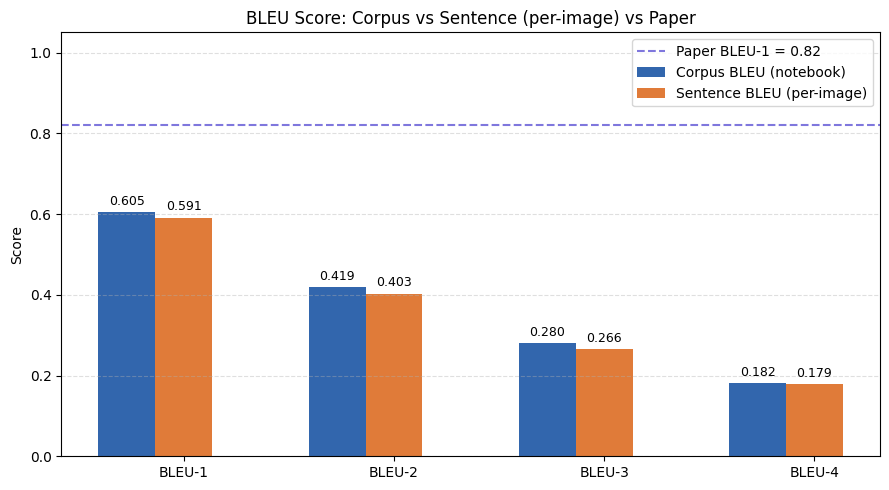

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import numpy as np

# ── 1. Corpus BLEU (cara akademis / standar) ──────────────────────────────
references = []
hypotheses = []

for img_name in tqdm(test_imgs, desc="Corpus BLEU"):
    actual_captions = [cap.replace("<start> ","").replace(" <end>","").split()
                       for cap in mapping[img_name]]
    generated_caption = generate_caption(img_name).split()
    references.append(actual_captions)
    hypotheses.append(generated_caption)

corpus_b1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0))
corpus_b2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0))
corpus_b3 = corpus_bleu(references, hypotheses, weights=(0.33,0.33,0.33,0))
corpus_b4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25))

print(f"[Corpus BLEU] BLEU-1: {corpus_b1:.4f}  BLEU-2: {corpus_b2:.4f}  BLEU-3: {corpus_b3:.4f}  BLEU-4: {corpus_b4:.4f}")

# ── 2. Sentence BLEU (cara paper) — rata-rata per gambar ──────────────────
smoothie = SmoothingFunction().method4   # smoothing agar tidak 0 pada n-gram tinggi

sent_b1_list, sent_b2_list, sent_b3_list, sent_b4_list = [], [], [], []

for refs, hyp in tqdm(zip(references, hypotheses), total=len(hypotheses), desc="Sentence BLEU"):
    sent_b1_list.append(sentence_bleu(refs, hyp, weights=(1,0,0,0),         smoothing_function=smoothie))
    sent_b2_list.append(sentence_bleu(refs, hyp, weights=(0.5,0.5,0,0),     smoothing_function=smoothie))
    sent_b3_list.append(sentence_bleu(refs, hyp, weights=(0.33,0.33,0.33,0),smoothing_function=smoothie))
    sent_b4_list.append(sentence_bleu(refs, hyp, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie))

sent_b1 = np.mean(sent_b1_list)
sent_b2 = np.mean(sent_b2_list)
sent_b3 = np.mean(sent_b3_list)
sent_b4 = np.mean(sent_b4_list)

print(f"[Sentence BLEU] BLEU-1: {sent_b1:.4f}  BLEU-2: {sent_b2:.4f}  BLEU-3: {sent_b3:.4f}  BLEU-4: {sent_b4:.4f}")

# ── 3. Tabel perbandingan dengan paper ────────────────────────────────────
print("
" + "="*62)
print(f"  {"Metrik":<18} {"Corpus BLEU":>13} {"Sentence BLEU":>14} {"Paper":>9}")
print("="*62)
paper = {"BLEU-1": 0.82, "BLEU-2": None, "BLEU-3": None, "BLEU-4": None}
rows = [
    ("BLEU-1", corpus_b1, sent_b1, 0.82),
    ("BLEU-2", corpus_b2, sent_b2, None),
    ("BLEU-3", corpus_b3, sent_b3, None),
    ("BLEU-4", corpus_b4, sent_b4, None),
]
for name, cb, sb, pap in rows:
    pap_str = f"{pap:.4f}" if pap else "  —   "
    print(f"  {name:<18} {cb:>13.4f} {sb:>14.4f} {pap_str:>9}")
print("="*62)

# ── 4. Visualisasi gabungan ───────────────────────────────────────────────
labels  = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
c_vals  = [corpus_b1, corpus_b2, corpus_b3, corpus_b4]
s_vals  = [sent_b1,   sent_b2,   sent_b3,   sent_b4]
p_vals  = [0.82, None, None, None]

x = np.arange(len(labels))
width = 0.27

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, c_vals, width, label="Corpus BLEU (notebook)",   color="#3266ad")
bars2 = ax.bar(x,         s_vals, width, label="Sentence BLEU (per-image)", color="#e07b39")

# Garis referensi paper (hanya BLEU-1)
ax.axhline(y=0.82, color="#7F77DD", linestyle="--", linewidth=1.5, label="Paper BLEU-1 = 0.82")

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("BLEU Score: Corpus vs Sentence (per-image) vs Paper")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
